<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/12_%E1%84%83%E1%85%A1%E1%86%AB%E1%84%87%E1%85%A2%E1%86%A8%E1%84%8C%E1%85%B5%E1%86%AF%E1%84%89%E1%85%A5%E1%86%AF%E1%84%80%E1%85%A8%E1%84%89%E1%85%B5%E1%86%B7%E1%84%92%E1%85%AA_ESM%E1%84%87%E1%85%A7%E1%86%AB%E1%84%8B%E1%85%B5%E1%84%89%E1%85%B3%E1%84%8F%E1%85%A2%E1%84%82%E1%85%B5%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 12 · 단백질 설계 — ESM-2 로 변이 스캐닝 & 단백질 공학
### 항체·효소를 '어디를 바꾸면 좋은지' AI 에게 묻기


바이오시밀러·항체·효소 의약품에서 **단백질 공학**(원하는 성질을 갖도록
아미노산을 바꾸는 것)은 핵심 기술입니다. 문제는 후보 변이의 수가
**천문학적**(길이 100이면 100×19=1900가지, 조합은 폭발적)이라는 점.
ESM-2 같은 **단백질 언어모델**은 수억 개 자연 단백질을 학습했기에,
**"어떤 아미노산이 그 자리에 자연스러운가"** 를 알고 있어, 실험 전에
유망한 변이를 **컴퓨터로 먼저 걸러줍니다.**

**이 노트북에서 배우는 것**
1. **단일 forward pass** 로 서열 전체의 **변이 점수 지도(deep mutational scan)** 만들기
2. **히트맵**으로 어디가 보존적(못 바꿈)이고 어디가 유연(바꿔도 됨)인지 시각화
3. 가장 **해로운/허용되는** 변이 Top 목록 뽑기 → 실험 우선순위
4. ESM **임베딩**으로 단백질 간 유사도·기능 관계 파악
5. 항체 최적화·효소 안정화에서의 활용 패턴

> 💡 런타임을 **T4 GPU** 로 바꾸면 빠릅니다. (CPU 로도 동작, 소형 모델 사용)


## 단백질 언어 모델(PLM)과 ESM-2

### 1. 왜 '언어 모델'인가?
단백질은 20종의 아미노산이라는 '글자'로 쓰여진 '문장'과 같습니다. 자연어 처리(NLP)에서 단어의 주변 맥락을 통해 문법과 의미를 배우듯, **ESM-2**는 수억 개의 단백질 서열을 학습하며 **생물학적 문법**을 익힙니다.
- **서열 = 문장**: 아미노산의 배열순서
- **구조/기능 = 의미**: 특정 배열이 만드는 3차원 모양과 화학적 활성

### 2. 진화적 스케일의 모델링 (Evolutionary Scale Modeling)
자연계에 존재하는 단백질들은 수십억 년의 진화 과정을 거쳐 '살아남은' 서열들입니다. 모델이 이 서열들을 학습했다는 것은, **"어떤 위치에 어떤 아미노산이 오는 것이 생존(기능 유지)에 유리한가"**라는 진화적 선택 압력을 데이터로 이해했다는 뜻입니다.

### 3. 변이 효과 예측의 원리: Wild-type Marginals
본 실습에서 사용한 기법은 다음과 같은 논리를 따릅니다.
- **Likelihood (우도)**: 모델이 특정 위치에서 특정 아미노산을 높은 확률로 예측한다면, 그 아미노산은 해당 위치의 구조나 기능을 유지하는 데 자연스럽고 필수적일 가능성이 높습니다.
- **Log-Likelihood Ratio**:
  $$\text{Score} = \log P(A_{variant}) - \log P(A_{wildtype})$$
  - 이 값이 **음수**라면: 자연 상태보다 훨씬 불안정하거나 기능이 저하될 '해로운 변이'로 해석합니다.
  - 이 값이 **0에 가깝거나 양수**라면: 진화적으로 허용되거나, 오히려 더 나은 성질을 가질 수도 있는 '유망한 후보'입니다.

### 4. 단백질 공학에의 응용
- **항체 최적화**: 결합력(Affinity)은 유지하면서 면역원성을 낮추거나 안정성을 높이는 지점을 찾습니다.
- **효소 개량**: 열에 강하게 만들거나(Thermal stability) 반응 속도를 높이기 위해 '유연한 위치'를 타겟팅하여 라이브러리 크기를 줄입니다.

In [1]:
!pip install transformers torch matplotlib -q
import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForMaskedLM
device = "cuda" if torch.cuda.is_available() else "cpu"
print("준비 완료 ✅  (device:", device, ")")


준비 완료 ✅  (device: cuda )


## 1. ESM-2 단백질 언어모델 로드 (마스크 예측용)
예제 15와 같은 경량 ESM-2 를 씁니다. 이번엔 **각 위치에서 20종 아미노산의
확률**을 뽑는 `MaskedLM` 헤드를 사용합니다. 이 확률이 변이 점수의 근거입니다.


In [3]:
esm_name = "facebook/esm2_t12_35M_UR50D"
tok = AutoTokenizer.from_pretrained(esm_name)
mlm = AutoModelForMaskedLM.from_pretrained(esm_name).to(device).eval()

# 예제 단백질 서열 (데모용 70여 잔기). 실무에선 항체 CDR·효소 활성부위를 넣음
seq = ("MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSGAEKAVQVKVKALPDAQFEVVHSLAKWKR")
print("서열 길이:", len(seq), "잔기")
print("ESM-2 로드 완료 ✅")


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

서열 길이: 78 잔기
ESM-2 로드 완료 ✅


## 2. ⭐ 변이 점수 지도 — 단일 forward pass 로 전체 스캔
표준 기법(**wild-type marginals**): 야생형 서열을 **한 번만** 모델에 넣고,
각 위치에서 20종 아미노산의 로그확률을 얻습니다.
변이 점수 = log P(변이 아미노산) − log P(야생형).
**점수가 음수로 클수록 '해로운(비자연스러운)' 변이**로 예측됩니다.


In [4]:
AAs = list("ACDEFGHIKLMNPQRSTVWY")   # 표준 20 아미노산

# 야생형 서열 1회 통과 → 모든 위치의 로그확률 확보
enc = tok(seq, return_tensors="pt").to(device)
with torch.no_grad():
    logits = mlm(**enc).logits[0]                 # (토큰수, 어휘)
logp = F.log_softmax(logits, dim=-1)              # 로그확률

aa_ids = {a: tok.convert_tokens_to_ids(a) for a in AAs}
L = len(seq)
score = np.zeros((20, L))                          # 20 x 길이
for j, wt in enumerate(seq):
    pos_tok = j + 1                                # [CLS] 보정
    wt_lp = logp[pos_tok, aa_ids[wt]].item()
    for i, a in enumerate(AAs):
        score[i, j] = logp[pos_tok, aa_ids[a]].item() - wt_lp
print("변이 점수 지도 shape:", score.shape, "(20 아미노산 x", L, "위치)")
print("→ 단 한 번의 모델 실행으로 모든 변이를 점수화했습니다")


변이 점수 지도 shape: (20, 78) (20 아미노산 x 78 위치)
→ 단 한 번의 모델 실행으로 모든 변이를 점수화했습니다


## 3. ⭐ 히트맵 — 어디를 바꿔도 되고, 어디는 절대 안 되는지
파란색(음수)=해로운 변이, 빨간색(0 근처)=허용 가능.
**세로 줄 전체가 파란 위치 = 보존적(기능에 필수)**,
얼룩덜룩한 위치 = 변이 허용도가 높은 곳입니다.


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,833 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


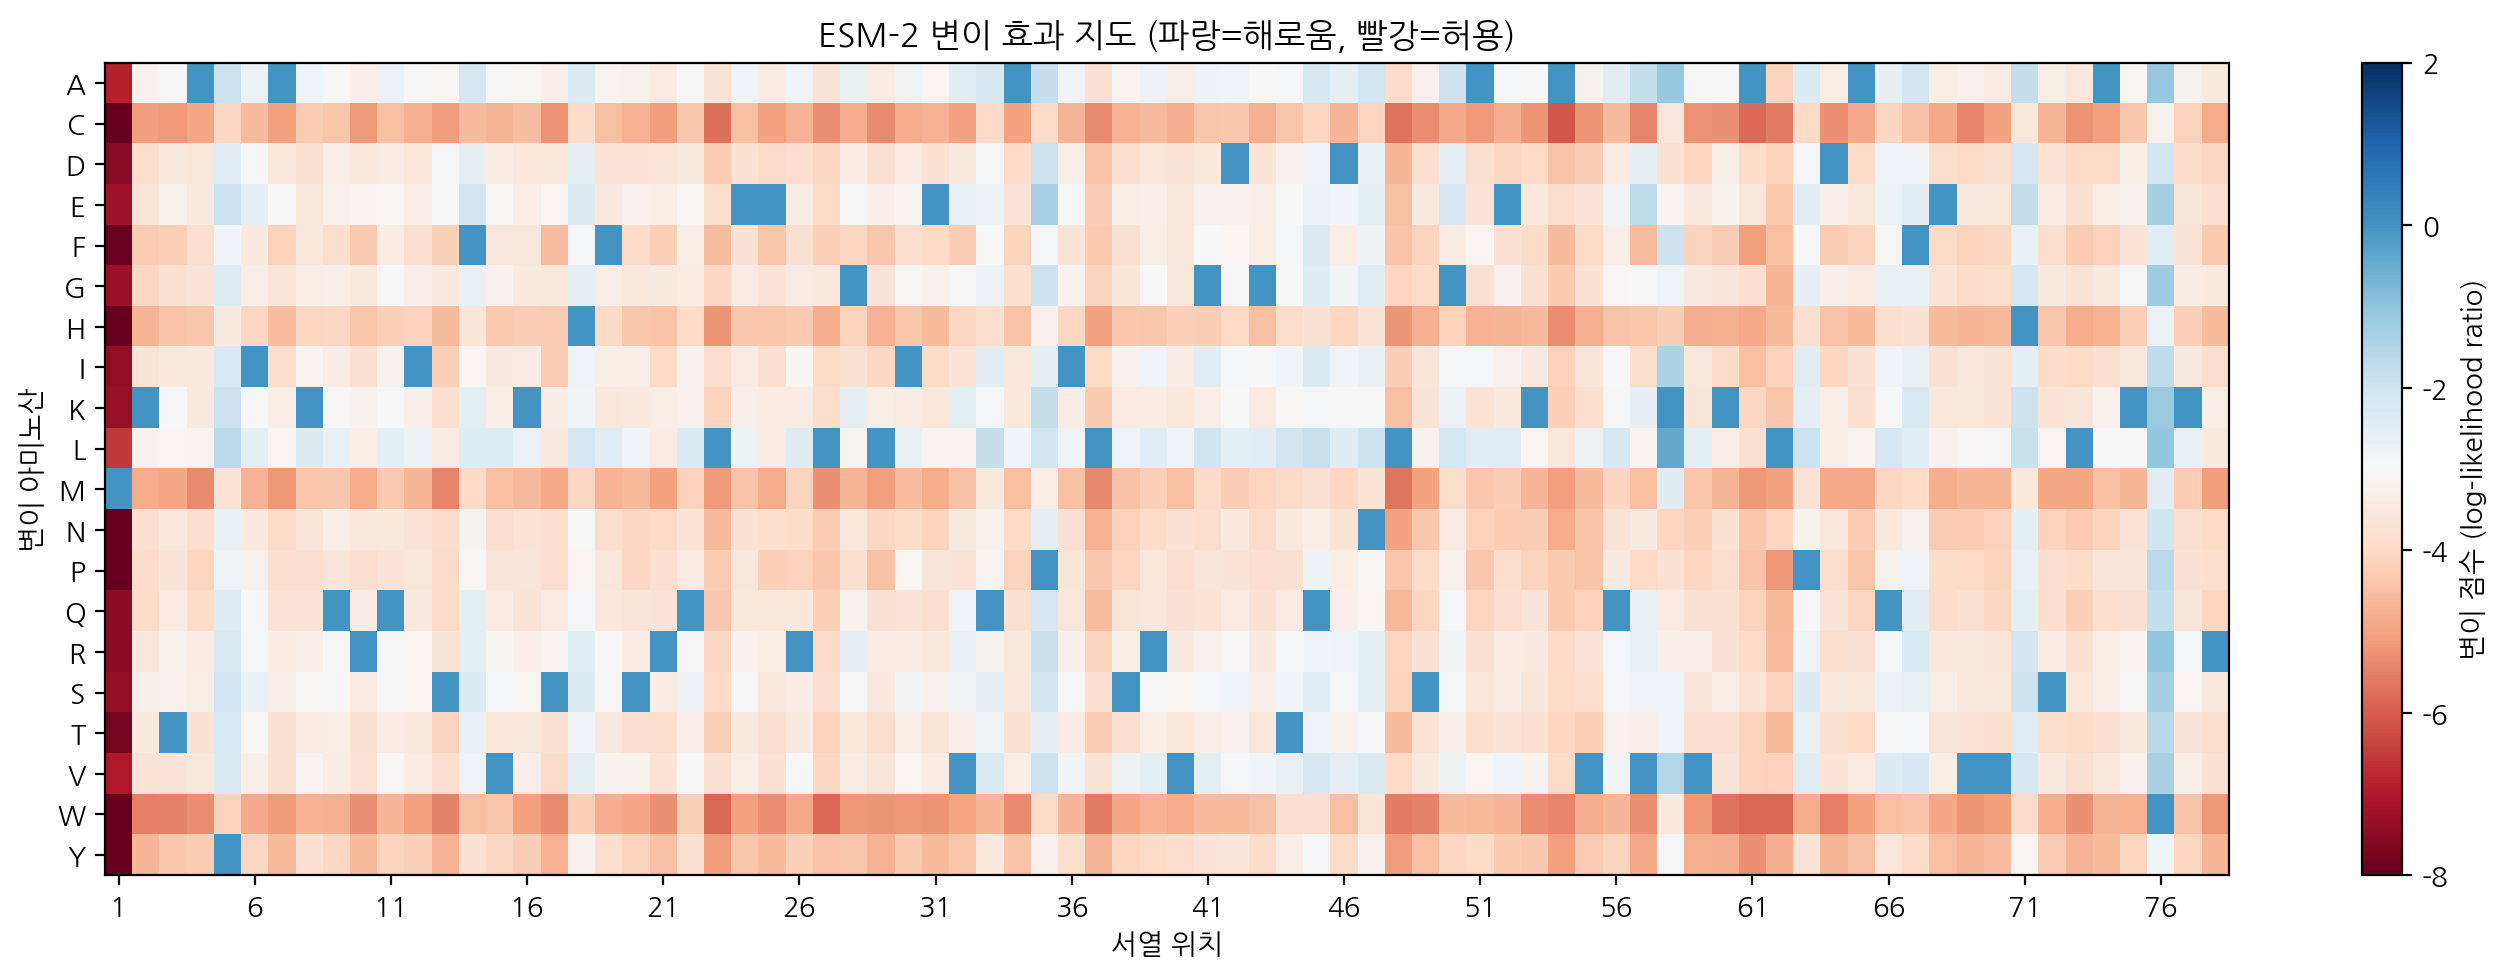

In [5]:
# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(score, aspect="auto", cmap="RdBu", vmin=-8, vmax=2)
ax.set_yticks(range(20)); ax.set_yticklabels(AAs)
ax.set_xticks(range(0, L, 5)); ax.set_xticklabels(range(1, L+1, 5))
ax.set_xlabel("서열 위치"); ax.set_ylabel("변이 아미노산")
ax.set_title("ESM-2 변이 효과 지도 (파랑=해로움, 빨강=허용)")
plt.colorbar(im, label="변이 점수 (log-likelihood ratio)")
plt.tight_layout(); plt.show()


## 4. 보존 위치 vs 유연 위치 찾기 (단백질 공학 힌트)
위치별 **평균 변이 점수**가 낮을수록(=대부분 변이가 해로움) 보존적이고 중요한
자리입니다. 반대로 높은 위치는 자유롭게 엔지니어링할 수 있는 후보입니다.


In [6]:
pos_mean = score.mean(axis=0)                      # 위치별 평균 변이 점수
order = np.argsort(pos_mean)

print("■ 가장 보존적인(건드리면 안 되는) 위치 Top5")
for j in order[:5]:
    print(f"   위치 {j+1:2d} ({seq[j]}): 평균점수 {pos_mean[j]:+.2f}  → 기능에 필수 가능성")

print("\n■ 가장 유연한(엔지니어링 여지 큰) 위치 Top5")
for j in order[::-1][:5]:
    print(f"   위치 {j+1:2d} ({seq[j]}): 평균점수 {pos_mean[j]:+.2f}  → 변이 허용도 높음")


■ 가장 보존적인(건드리면 안 되는) 위치 Top5
   위치  1 (M): 평균점수 -7.30  → 기능에 필수 가능성
   위치 48 (L): 평균점수 -4.42  → 기능에 필수 가능성
   위치 62 (L): 평균점수 -4.37  → 기능에 필수 가능성
   위치 54 (A): 평균점수 -4.27  → 기능에 필수 가능성
   위치 23 (L): 평균점수 -4.23  → 기능에 필수 가능성

■ 가장 유연한(엔지니어링 여지 큰) 위치 Top5
   위치 76 (W): 평균점수 -1.71  → 변이 허용도 높음
   위치 35 (P): 평균점수 -2.36  → 변이 허용도 높음
   위치 71 (H): 평균점수 -2.37  → 변이 허용도 높음
   위치  5 (Y): 평균점수 -2.47  → 변이 허용도 높음
   위치 58 (K): 평균점수 -2.65  → 변이 허용도 높음


## 5. 유망한 변이 / 위험한 변이 Top 목록
개별 변이 단위로도 순위를 매길 수 있습니다. 실험을 어디부터 할지 정하는
**우선순위 리스트**가 됩니다 (항체 친화도 개선 후보 등).


In [7]:
records = []
for j, wt in enumerate(seq):
    for i, a in enumerate(AAs):
        if a != wt:
            records.append((f"{wt}{j+1}{a}", score[i, j]))
records.sort(key=lambda x: x[1])

print("■ 가장 해로울 것으로 예측되는 변이 Top5 (피해야 할 것)")
for name, s in records[:5]:
    print(f"   {name}: {s:+.2f}")
print("\n■ 가장 허용/선호될 변이 Top5 (개선 후보로 실험 우선)")
for name, s in records[::-1][:5]:
    print(f"   {name}: {s:+.2f}")


■ 가장 해로울 것으로 예측되는 변이 Top5 (피해야 할 것)
   M1W: -8.89
   M1C: -8.72
   M1H: -8.61
   M1Y: -8.46
   M1N: -7.99

■ 가장 허용/선호될 변이 Top5 (개선 후보로 실험 우선)
   K58L: -0.45
   W76L: -1.07
   W76R: -1.09
   K58A: -1.11
   W76A: -1.12


## 6. ESM 임베딩으로 단백질 관계 보기
임베딩(의미 벡터)은 서열이 달라도 **기능이 비슷하면 가까이** 위치합니다.
서로 다른 단백질들의 유사도를 비교해 봅니다 (기능 예측·분류의 기반).


In [8]:
from transformers import AutoModel
emb_model = AutoModel.from_pretrained(esm_name).to(device).eval()

def embed(s):
    e = tok(s, return_tensors="pt").to(device)
    with torch.no_grad():
        h = emb_model(**e).last_hidden_state[0]
    return h.mean(0).cpu().numpy()                 # 평균 풀링 = 단백질 1개 벡터

seqs = {
 "원본":       seq,
 "보존변이(유해)": seq[:4] + "P" + seq[5:],         # 보존위치를 Pro로 (해로울 것)
 "유연변이(무해)": seq[:0] + seq,                   # 거의 동일
 "무관단백질":   "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKT",  # 인슐린 일부
}
names = list(seqs); V = np.stack([embed(s) for s in seqs.values()])
Vn = V / np.linalg.norm(V, axis=1, keepdims=True)
sim = Vn @ Vn.T
print("코사인 유사도 행렬:")
print("        " + "  ".join(f"{n[:6]:>6}" for n in names))
for i, n in enumerate(names):
    print(f"{n[:6]:>6} " + "  ".join(f"{sim[i,j]:6.2f}" for j in range(len(names))))
print("\n→ 원본과 무관단백질은 유사도가 낮고, 유사 서열끼리는 높게 나옵니다")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


코사인 유사도 행렬:
            원본  보존변이(유  유연변이(무   무관단백질
    원본   1.00    1.00    1.00    0.92
보존변이(유   1.00    1.00    1.00    0.92
유연변이(무   1.00    1.00    1.00    0.92
 무관단백질   0.92    0.92    0.92    1.00

→ 원본과 무관단백질은 유사도가 낮고, 유사 서열끼리는 높게 나옵니다


## 7. 단백질 언어모델 활용 지형도 (참고)
| 목적 | 방법 | 현장 예 |
|---|---|---|
| **변이 효과 예측** | ESM 마스크 확률 (이 예제) | 항체 친화도·안정성 개선 후보 선별 |
| **기능·분류 예측** | ESM 임베딩 + 분류기 | 효소 기능, 세포 위치 예측 |
| **구조 예측** | ESMFold (예제 13) | 서열→3D, 결합부위 파악 |
| **서열 생성/설계** | ProtGPT2, ESM-IF | 신규 단백질·효소 de novo 설계 |

**표준 워크플로우**: 변이 스캔으로 후보 축소 → 임베딩·구조로 검증 →
소수 후보만 실제 실험 → **실험 횟수·비용 대폭 절감**


## 정리 & 현장 응용
- **ESM-2 변이 스캐닝**: 단 한 번의 모델 실행으로 서열 전체 변이 지도를 얻는다
- **보존/유연 위치 구분**: 어디는 지키고 어디를 엔지니어링할지 실험 전에 판단
- **임베딩**: 서열→기능 관계 파악 → 기능 예측·분류의 입력
- 항체 최적화, 효소 안정화, 바이오시밀러 개발에서 **실험 후보를 대폭 축소**
- 구조예측·임베딩과 연결하면 **단백질 AI 파이프라인** 완성
